In [6]:
!cp -r /content/drive/MyDrive/photodata /content/

cp: cannot stat '/content/drive/MyDrive/photodata/pneumoniaClassifier1.1.keras': No such file or directory


In [4]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os
from google.colab import drive

In [5]:
drive.mount('/content/drive')
path = "/content/drive/MyDrive/photodata/"

Mounted at /content/drive


In [7]:
size = 64
epochs = 100

In [13]:
IMAGE_SIZE = (size, size)
BATCH_SIZE = 32

def load_data(folder_path):
    dataset = keras.utils.image_dataset_from_directory(
        folder_path,
        image_size=IMAGE_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="binary",
        class_names=["normal", "pneumonia"]
    )

    class_names = dataset.class_names   # save before caching

    dataset = dataset.cache()
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset, class_names


train_data, class_names = load_data("/content/photodata/train")
test_data, _ = load_data("/content/photodata/test")

Found 11937 files belonging to 2 classes.
Found 1505 files belonging to 2 classes.


/tmp/ipykernel_1836/3958442303.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label_index = int(labels[i].numpy())


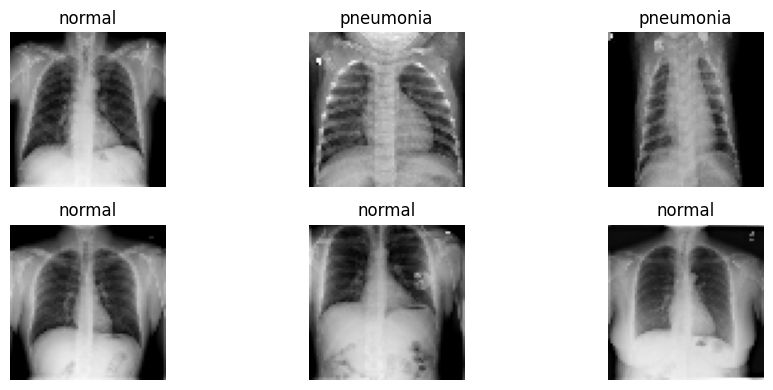

In [15]:
def show_sample_images(dataset):
    images, labels = next(iter(dataset))  # grab the first batch

    plt.figure(figsize=(10, 4))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_index = int(labels[i].numpy())
        plt.title(class_names[label_index])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_images(train_data)

In [16]:
def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_data = train_data.map(normalize)
test_data  = test_data.map(normalize)

In [17]:
def build_model():
    model = keras.Sequential([
        # --- Feature detection ---
        keras.layers.Conv2D(16, (3, 3), activation="relu", input_shape=(size, size, 3)),
        keras.layers.MaxPooling2D(),

        keras.layers.Conv2D(32, (3, 3), activation="relu"),
        keras.layers.MaxPooling2D(),

        # --- Decision making ---
        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid")  # output: 0 = benign, 1 = malignant
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,625 (1.55 MB)

 Trainable params: 406,625 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
MODEL_PATH   = "/content/drive/MyDrive/photodata/pneumoniaClassifierNormal.keras"

if os.path.exists(MODEL_PATH):
    print("Loading saved model...")
    model = keras.models.load_model(MODEL_PATH)
    history = None  # no history since we skipped training
else:
    print("No saved model found. Training from scratch...")
    model = build_model()
    history = model.fit(
        train_data,
        epochs=epochs,
        validation_data=test_data
    )
    model.save(MODEL_PATH)
    print("Model saved!")


No saved model found. Training from scratch...
Epoch 1/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 183s 473ms/step - accuracy: 0.8157 - loss: 0.3802 - val_accuracy: 0.8884 - val_loss: 0.2136
Epoch 2/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8829 - loss: 0.2339 - val_accuracy: 0.8897 - val_loss: 0.2043
Epoch 3/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8866 - loss: 0.2151 - val_accuracy: 0.8870 - val_loss: 0.2051
Epoch 4/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8858 - loss: 0.2050 - val_accuracy: 0.8877 - val_loss: 0.2061
Epoch 5/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8865 - loss: 0.2012 - val_accuracy: 0.8904 - val_loss: 0.2020
Epoch 6/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8876 - loss: 0.1932 - val_accuracy: 0.8884 - val_loss: 0.2060
Epoch 7/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8910 - loss: 0.1902 - val_accuracy: 0.8910 - val_loss: 0.2126
Epoch 8/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 2s 4m

In [20]:
all_images, all_labels = [], []
for images, labels in test_data:
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

all_images       = np.concatenate(all_images, axis=0)
all_labels       = np.concatenate(all_labels, axis=0).astype(int)
predictions      = model.predict(all_images)
predicted_labels = (predictions > 0.5).astype(int).flatten()
class_names      = ["Normal", "Pneumonia"]

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


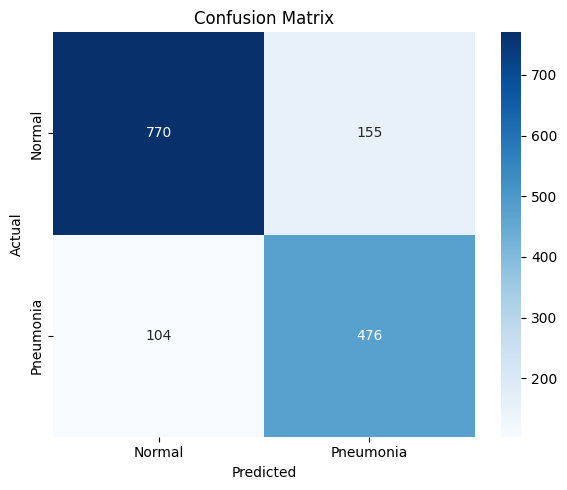

In [21]:
cm = confusion_matrix(all_labels, predicted_labels)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [22]:
print("\nClassification Report:")
print(classification_report(all_labels, predicted_labels, target_names=class_names))



Classification Report:
              precision    recall  f1-score   support

      Normal       0.88      0.83      0.86       925
   Pneumonia       0.75      0.82      0.79       580

    accuracy                           0.83      1505
   macro avg       0.82      0.83      0.82      1505
weighted avg       0.83      0.83      0.83      1505



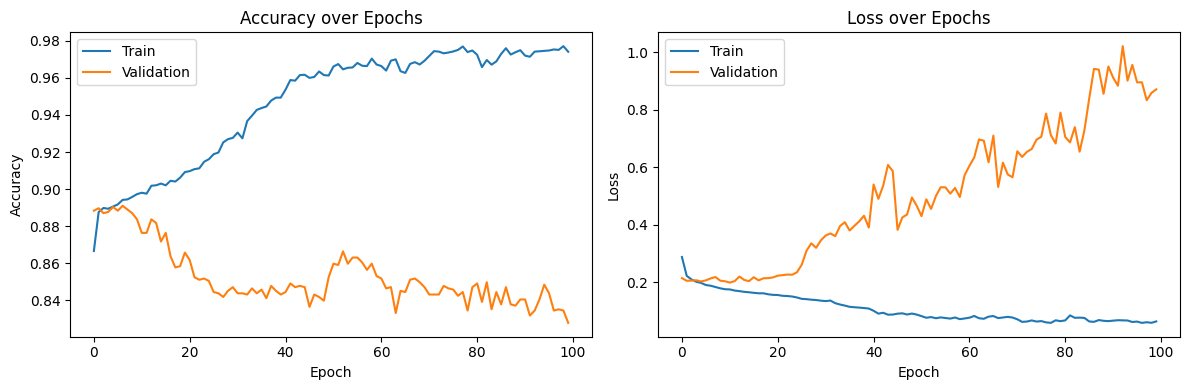

In [23]:
if history is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history["accuracy"],     label="Train")
    ax1.plot(history.history["val_accuracy"], label="Validation")
    ax1.set_title("Accuracy over Epochs")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history.history["loss"],     label="Train")
    ax2.plot(history.history["val_loss"], label="Validation")
    ax2.set_title("Loss over Epochs")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print("No training history available (model was loaded from file).")